In [2]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
import seaborn as sns
from tqdm import tqdm
import json

import segmentation_models_pytorch as smp

from transformers import SegformerForSemanticSegmentation
from transformers import SegformerFeatureExtractor

torch.manual_seed(42)
np.random.seed(42)

In [6]:
!pip install segmentation_models_pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 43.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

In [3]:
class CamVidDataset(Dataset):
    def __init__(self, root_dir, feature_extractor=None, transform=None, split='train'):
        self.root_dir = root_dir
        self.split = split
        self.transform = transform
        self.feature_extractor = feature_extractor

        self.images_dir = os.path.join(root_dir, split)
        self.masks_dir = os.path.join(root_dir, split+'_labels')

        self.image_files = sorted([f for f in os.listdir(self.images_dir) if f.endswith('.png')])
        self.mask_files = sorted([f for f in os.listdir(self.masks_dir) if f.endswith('.png')])

        self.classes = [
            'Sky', 'Building', 'Pole', 'Road', 'Sidewalk',
            'Tree', 'SignSymbol', 'Fence', 'Car', 'Pedestrian',
            'Bicyclist', 'Unlabelled'
        ]
        self.class_colors = [
            (128, 128, 128), (128, 0, 0), (192, 192, 128), (128, 64, 128), (0, 0, 192),
            (128, 128, 0), (192, 128, 128), (64, 64, 128), (64, 0, 128), (64, 64, 0),
            (0, 128, 192), (0, 0, 0)
        ]

        self.class2idx = {cls: idx for idx, cls in enumerate(self.classes)}
        self.idx2class = {idx: cls for idx, cls in enumerate(self.classes)}

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.images_dir, self.image_files[idx])
        mask_path = os.path.join(self.masks_dir, self.mask_files[idx])

        image = Image.open(img_path).convert('RGB')
        mask = Image.open(mask_path)

        mask = np.array(mask)
        class_mask = np.zeros(mask.shape[:2], dtype=np.uint8)

        for i, color in enumerate(self.class_colors):
            class_mask[(mask == color).all(axis=-1)] = i

        class_mask = Image.fromarray(class_mask)

        if self.transform:
            image = self.transform(image)
            class_mask = self.transform(class_mask)

        if self.feature_extractor:
            inputs = self.feature_extractor(images=image, segmentation_maps=class_mask)
            image = inputs['pixel_values'][0]
            class_mask = inputs['labels'][0]
        else:
            image = transforms.ToTensor()(image)
            class_mask = torch.from_numpy(np.array(class_mask)).long()

        return image, class_mask

def get_dataloaders(batch_size=8, feature_extractor=None):
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
    ])

    train_dataset = CamVidDataset('archive/CamVid', feature_extractor, transform, 'train')
    val_dataset = CamVidDataset('archive/CamVid', feature_extractor, transform, 'val')
    test_dataset = CamVidDataset('archive/CamVid', feature_extractor, transform, 'test')

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

    return train_loader, val_loader, test_loader, train_dataset.classes

In [4]:
def create_unet():
    model = smp.Unet(
        encoder_name="resnet34",
        encoder_weights="imagenet",
        in_channels=3,
        classes=12,
    )
    return model

def create_segformer():
    model = SegformerForSemanticSegmentation.from_pretrained(
        "nvidia/mit-b0",
        num_labels=12,
        ignore_mismatched_sizes=True
    )
    feature_extractor = SegformerFeatureExtractor.from_pretrained("nvidia/mit-b0")
    feature_extractor.reduce_labels = False
    feature_extractor.size = 256

    return model, feature_extractor

In [5]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=10, model_type='unet'):
    model = model.to(device)
    train_losses = []
    val_losses = []
    val_accuracies = []
    val_f1_scores = []

    best_val_loss = float('inf')

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        start_time = time.time()

        for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()

            if model_type == 'segformer':
                outputs = model(pixel_values=images, labels=masks)
                loss = outputs.loss
                logits = outputs.logits
            else:
                outputs = model(images)
                loss = criterion(outputs, masks)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        model.eval()
        val_loss = 0.0
        all_preds = []
        all_masks = []

        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device)
                masks = masks.to(device)

                if model_type == 'segformer':
                    outputs = model(pixel_values=images, labels=masks)
                    batch_loss = outputs.loss
                    logits = outputs.logits
                    preds = torch.argmax(logits, dim=1)
                else:
                    outputs = model(images)
                    batch_loss = criterion(outputs, masks)
                    preds = torch.argmax(outputs, dim=1)

                val_loss += batch_loss.item()
                all_preds.extend(preds.cpu().numpy().flatten())
                all_masks.extend(masks.cpu().numpy().flatten())

        epoch_train_loss = running_loss / len(train_loader)
        epoch_val_loss = val_loss / len(val_loader)

        labeled_idx = np.array(all_masks) != 11
        filtered_preds = np.array(all_preds)[labeled_idx]
        filtered_masks = np.array(all_masks)[labeled_idx]

        accuracy = accuracy_score(filtered_masks, filtered_preds)
        f1 = f1_score(filtered_masks, filtered_preds, average='weighted')

        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)
        val_accuracies.append(accuracy)
        val_f1_scores.append(f1)

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), f'best_{model_type}_model.pth')

        epoch_time = time.time() - start_time
        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}")
        print(f"Accuracy: {accuracy:.4f}, F1 Score: {f1:.4f}, Time: {epoch_time:.2f}s")

    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_accuracies': val_accuracies,
        'val_f1_scores': val_f1_scores
    }

def evaluate_model(model, test_loader, device, model_type='unet'):
    model.eval()
    all_preds = []
    all_masks = []

    with torch.no_grad():
        for images, masks in test_loader:
            images = images.to(device)
            masks = masks.to(device)

            if model_type == 'segformer':
                outputs = model(pixel_values=images)
                logits = outputs.logits
                preds = torch.argmax(logits, dim=1)
            else:
                outputs = model(images)
                preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy().flatten())
            all_masks.extend(masks.cpu().numpy().flatten())

    labeled_idx = np.array(all_masks) != 11
    filtered_preds = np.array(all_preds)[labeled_idx]
    filtered_masks = np.array(all_masks)[labeled_idx]

    accuracy = accuracy_score(filtered_masks, filtered_preds)
    f1 = f1_score(filtered_masks, filtered_preds, average='weighted')
    cm = confusion_matrix(filtered_masks, filtered_preds)

    return accuracy, f1, cm

def plot_metrics(unet_results, segformer_results, classes):
    plt.figure(figsize=(15, 10))

    plt.subplot(2, 2, 1)
    plt.plot(unet_results['train_losses'], label='U-Net Train')
    plt.plot(unet_results['val_losses'], label='U-Net Val')
    plt.plot(segformer_results['train_losses'], label='SegFormer Train')
    plt.plot(segformer_results['val_losses'], label='SegFormer Val')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(2, 2, 2)
    plt.plot(unet_results['val_accuracies'], label='U-Net')
    plt.plot(segformer_results['val_accuracies'], label='SegFormer')
    plt.title('Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(2, 2, 3)
    plt.plot(unet_results['val_f1_scores'], label='U-Net')
    plt.plot(segformer_results['val_f1_scores'], label='SegFormer')
    plt.title('Validation F1 Score')
    plt.xlabel('Epoch')
    plt.ylabel('F1 Score')
    plt.legend()

    plt.tight_layout()
    plt.savefig('training_metrics.png')
    plt.show()

def plot_confusion_matrix(cm, classes, title='Confusion Matrix'):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'{title.lower().replace(" ", "_")}.png')
    plt.show()

In [6]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_unet():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    unet = create_unet()

    unet_train_loader, unet_val_loader, unet_test_loader, classes = get_dataloaders(batch_size=8)

    num_epochs = 15
    criterion = nn.CrossEntropyLoss(ignore_index=11)

    print("Training U-Net...")
    unet_optimizer = torch.optim.Adam(unet.parameters(), lr=1e-4)
    unet_results = train_model(unet, unet_train_loader, unet_val_loader, criterion,
                             unet_optimizer, device, num_epochs, 'unet')

    print("\nEvaluating U-Net on test set...")
    unet.load_state_dict(torch.load('best_unet_model.pth'))
    unet_accuracy, unet_f1, unet_cm = evaluate_model(unet, unet_test_loader, device, 'unet')
    print(f"U-Net Test Accuracy: {unet_accuracy:.4f}, F1 Score: {unet_f1:.4f}")

    results = {
        'unet': {
            'accuracy': unet_accuracy,
            'f1': unet_f1,
            'parameters': count_parameters(unet),
            'train_losses': unet_results['train_losses'],
            'val_losses': unet_results['val_losses']
        }
    }

    with open('unet_results.json', 'w') as f:
        json.dump(results, f, indent=4)

In [8]:
train_unet()

Using device: cuda


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Training U-Net...


Epoch 1/15: 100%|██████████| 47/47 [01:38<00:00,  2.09s/it]


Epoch 1/15 - Train Loss: 1.9192, Val Loss: 1.3926
Accuracy: 0.6649, F1 Score: 0.6720, Time: 126.78s


...

Epoch 14/15 - Train Loss: 0.4368, Val Loss: 0.5267
Accuracy: 0.8589, F1 Score: 0.8425, Time: 116.25s


Epoch 15/15:   0%|          | 0/47 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Epoch 15/15: 100%|██████████| 47/47 [01:28<00:00,  1.88s/it]


Epoch 15/15 - Train Loss: 0.4232, Val Loss: 0.5238
Accuracy: 0.8589, F1 Score: 0.8420, Time: 116.68s

Evaluating U-Net on test set...


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


U-Net Test Accuracy: 0.8436, F1 Score: 0.8264


In [10]:
from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor

def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=10, model_type='unet'):
    model = model.to(device)
    train_losses = []
    val_losses = []
    val_accuracies = []
    val_f1_scores = []

    best_val_loss = float('inf')

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        start_time = time.time()

        for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()

            if model_type == 'segformer':
                outputs = model(pixel_values=images, labels=masks)
                loss = outputs.loss
            else:
                outputs = model(images)
                loss = criterion(outputs, masks)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        model.eval()
        val_loss = 0.0
        all_preds = []
        all_masks = []

        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device)
                masks = masks.to(device)

                if model_type == 'segformer':
                    outputs = model(pixel_values=images, labels=masks)
                    batch_loss = outputs.loss
                    logits = outputs.logits

                    upsampled_logits = nn.functional.interpolate(
                        logits,
                        size=masks.shape[-2:],
                        mode='bilinear',
                        align_corners=False
                    )
                    preds = torch.argmax(upsampled_logits, dim=1)
                else:
                    outputs = model(images)
                    batch_loss = criterion(outputs, masks)
                    preds = torch.argmax(outputs, dim=1)

                val_loss += batch_loss.item()

                if preds.shape != masks.shape:
                    preds = nn.functional.interpolate(
                        preds.unsqueeze(0).float(),
                        size=masks.shape[-2:],
                        mode='nearest'
                    ).squeeze(0).long()

                all_preds.append(preds.cpu().numpy().flatten())
                all_masks.append(masks.cpu().numpy().flatten())

        epoch_train_loss = running_loss / len(train_loader)
        epoch_val_loss = val_loss / len(val_loader)

        all_preds = np.concatenate(all_preds)
        all_masks = np.concatenate(all_masks)

        labeled_idx = all_masks != 11
        filtered_preds = all_preds[labeled_idx]
        filtered_masks = all_masks[labeled_idx]

        accuracy = accuracy_score(filtered_masks, filtered_preds)
        f1 = f1_score(filtered_masks, filtered_preds, average='weighted')

        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)
        val_accuracies.append(accuracy)
        val_f1_scores.append(f1)

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), f'best_{model_type}_model.pth')

        epoch_time = time.time() - start_time
        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}")
        print(f"Accuracy: {accuracy:.4f}, F1 Score: {f1:.4f}, Time: {epoch_time:.2f}s")

    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_accuracies': val_accuracies,
        'val_f1_scores': val_f1_scores
    }

def evaluate_model_1(model, test_loader, device, model_type='unet'):
    model.eval()
    all_preds = []
    all_masks = []

    with torch.no_grad():
        for images, masks in test_loader:
            images = images.to(device)
            masks = masks.to(device)

            if model_type == 'segformer':
                outputs = model(pixel_values=images)
                logits = outputs.logits

                upsampled_logits = nn.functional.interpolate(
                    logits,
                    size=masks.shape[-2:],
                    mode='bilinear',
                    align_corners=False
                )
                preds = torch.argmax(upsampled_logits, dim=1)
            else:
                outputs = model(images)
                preds = torch.argmax(outputs, dim=1)

            if preds.shape != masks.shape:
                preds = nn.functional.interpolate(
                    preds.unsqueeze(0).float(),
                    size=masks.shape[-2:],
                    mode='nearest'
                ).squeeze(0).long()

            all_preds.append(preds.cpu().numpy().flatten())
            all_masks.append(masks.cpu().numpy().flatten())

    all_preds = np.concatenate(all_preds)
    all_masks = np.concatenate(all_masks)

    labeled_idx = all_masks != 11
    filtered_preds = all_preds[labeled_idx]
    filtered_masks = all_masks[labeled_idx]

    accuracy = accuracy_score(filtered_masks, filtered_preds)
    f1 = f1_score(filtered_masks, filtered_preds, average='weighted')
    cm = confusion_matrix(filtered_masks, filtered_preds)

    return accuracy, f1, cm

def train_segformer():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    segformer = SegformerForSemanticSegmentation.from_pretrained(
        "nvidia/mit-b0",
        num_labels=12,
        ignore_mismatched_sizes=True
    )
    image_processor = SegformerImageProcessor.from_pretrained("nvidia/mit-b0")
    image_processor.reduce_labels = False
    image_processor.size = 256

    seg_train_loader, seg_val_loader, seg_test_loader, _ = get_dataloaders(
        batch_size=4,
        feature_extractor=image_processor
    )

    num_epochs = 15
    criterion = nn.CrossEntropyLoss(ignore_index=11)

    print("\nTraining SegFormer...")
    segformer_optimizer = torch.optim.Adam(segformer.parameters(), lr=5e-5)

    segformer_results = train_model(
        segformer,
        seg_train_loader,
        seg_val_loader,
        criterion,
        segformer_optimizer,
        device,
        num_epochs,
        'segformer'
    )

    print("\nEvaluating SegFormer on test set...")
    segformer.load_state_dict(torch.load('best_segformer_model.pth'))
    seg_accuracy, seg_f1, seg_cm = evaluate_model_1(
        segformer,
        seg_test_loader,
        device,
        'segformer'
    )
    print(f"SegFormer Test Accuracy: {seg_accuracy:.4f}, F1 Score: {seg_f1:.4f}")

    results = {
        'segformer': {
            'accuracy': seg_accuracy,
            'f1': seg_f1,
            'parameters': count_parameters(segformer),
            'train_losses': segformer_results['train_losses'],
            'val_losses': segformer_results['val_losses']
        }
    }

    with open('segformer_results.json', 'w') as f:
        json.dump(results, f, indent=4)

train_segformer()

Using device: cuda


Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/mit-b0 and are newly initialized: ['decode_head.batch_norm.bias', 'decode_head.batch_norm.num_batches_tracked', 'decode_head.batch_norm.running_mean', 'decode_head.batch_norm.running_var', 'decode_head.batch_norm.weight', 'decode_head.classifier.bias', 'decode_head.classifier.weight', 'decode_head.linear_c.0.proj.bias', 'decode_head.linear_c.0.proj.weight', 'decode_head.linear_c.1.proj.bias', 'decode_head.linear_c.1.proj.weight', 'decode_head.linear_c.2.proj.bias', 'decode_head.linear_c.2.proj.weight', 'decode_head.linear_c.3.proj.bias', 'decode_head.linear_c.3.proj.weight', 'decode_head.linear_fuse.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


preprocessor_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/transformers/utils/deprecation.py:172: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type'
  return func(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(



Training SegFormer...


...

Epoch 14/15 - Train Loss: 0.4748, Val Loss: 0.5353
Accuracy: 0.8524, F1 Score: 0.8427, Time: 116.24s


Epoch 15/15:   0%|          | 0/93 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Epoch 15/15: 100%|██████████| 93/93 [01:27<00:00,  1.07it/s]


Epoch 15/15 - Train Loss: 0.4673, Val Loss: 0.5373
Accuracy: 0.8524, F1 Score: 0.8422, Time: 111.60s

Evaluating SegFormer on test set...


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


SegFormer Test Accuracy: 0.8326, F1 Score: 0.8246


In [17]:
def plot_metrics(unet_results, segformer_results, classes):
    plt.figure(figsize=(15, 10))

    plt.subplot(2, 1, 1)
    plt.plot(unet_results['train_losses'], label='U-Net Train')
    plt.plot(unet_results['val_losses'], label='U-Net Val')
    plt.plot(segformer_results['train_losses'], label='SegFormer Train')
    plt.plot(segformer_results['val_losses'], label='SegFormer Val')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.savefig('training_validation_loss.png')
    plt.show()

def plot_confusion_matrix(cm, classes, title='Confusion Matrix'):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'{title.lower().replace(" ", "_")}.png')
    plt.show()

In [18]:
with open('unet_results.json', 'r') as f:
    unet_data = json.load(f)['unet']

with open('segformer_results.json', 'r') as f:
    segformer_data = json.load(f)['segformer']


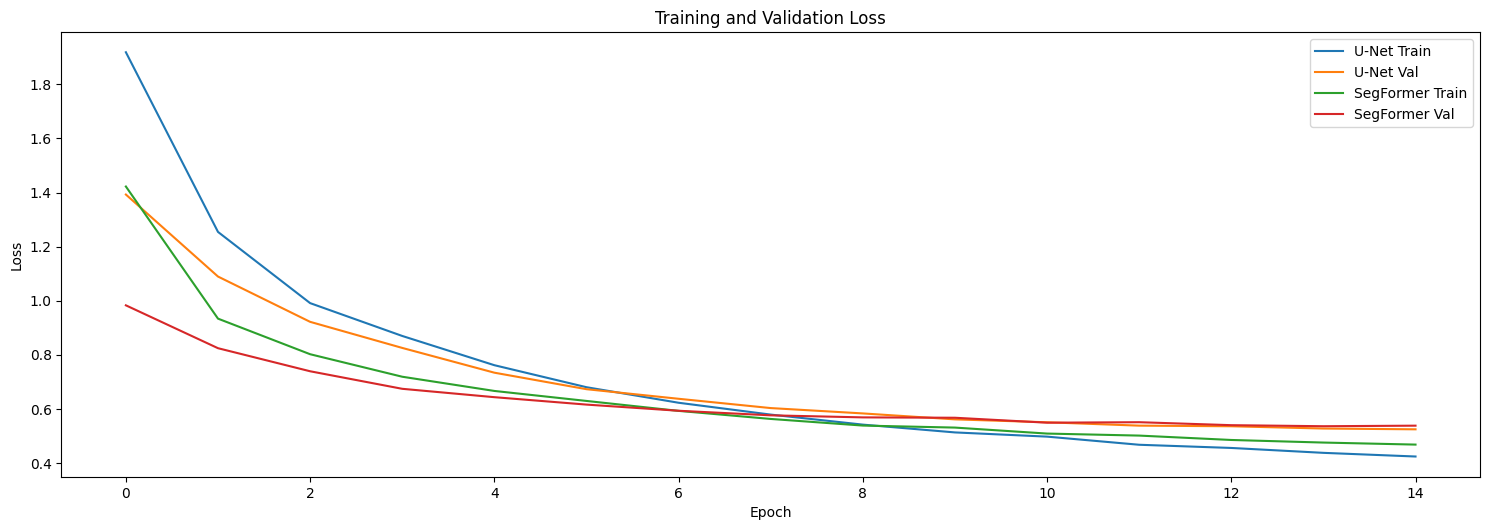

In [19]:
classes = [
    'Sky', 'Building', 'Pole', 'Road', 'Sidewalk',
    'Tree', 'SignSymbol', 'Fence', 'Car', 'Pedestrian',
    'Bicyclist', 'Unlabelled'
]

plot_metrics(unet_data, segformer_data, classes)

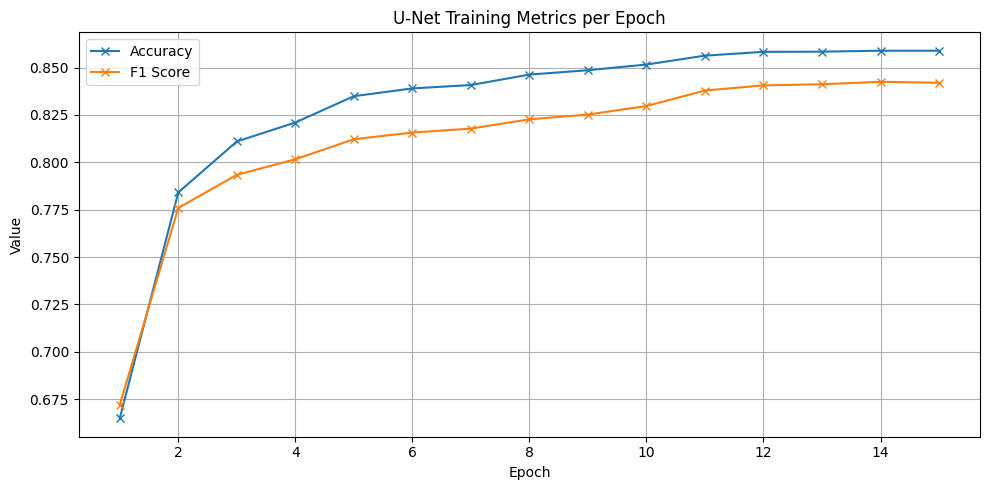

U-Net Test Accuracy: 0.8436, F1 Score: 0.8264



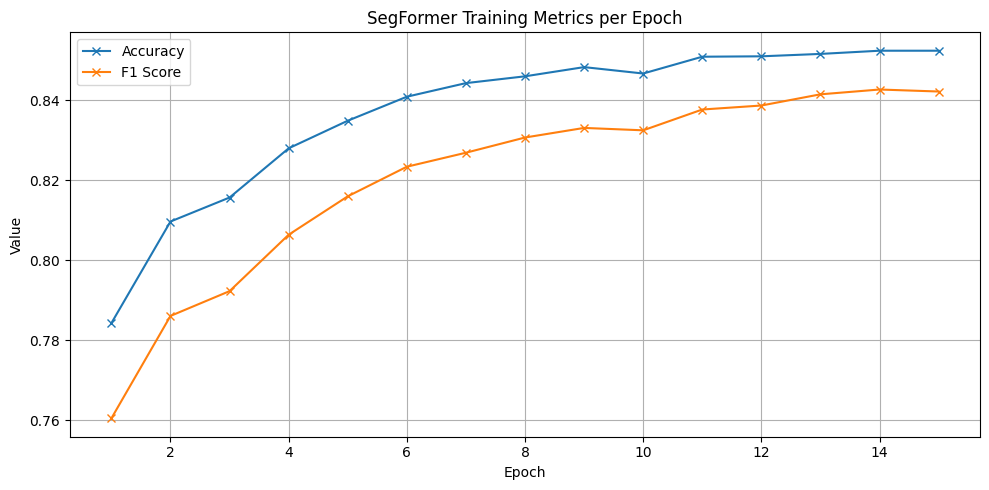

SegFormer Test Accuracy: 0.8326, F1 Score: 0.8246



In [29]:
unet_accuracies = [0.6649, 0.7841, 0.8110, 0.8210, 0.8349, 0.8390, 0.8408, 0.8463, 0.8486, 0.8516, 0.8563, 0.8583, 0.8584, 0.8589, 0.8589]
unet_f1_scores = [0.6720, 0.7759, 0.7934, 0.8016, 0.8122, 0.8157, 0.8178, 0.8227, 0.8252, 0.8297, 0.8379, 0.8406, 0.8412, 0.8425, 0.8420]
unet_test_accuracy = 0.8436
unet_test_f1 = 0.8264

segformer_accuracies = [0.7843, 0.8097, 0.8157, 0.8280, 0.8349, 0.8409, 0.8443, 0.8460, 0.8483, 0.8467, 0.8509, 0.8510, 0.8516, 0.8524, 0.8524]
segformer_f1_scores = [0.7605, 0.7861, 0.7923, 0.8064, 0.8160, 0.8234, 0.8269, 0.8307, 0.8331, 0.8325, 0.8377, 0.8387, 0.8415, 0.8427, 0.8422]
segformer_test_accuracy = 0.8326
segformer_test_f1 = 0.8246

def plot_training_curves(model_name, accuracies, f1_scores, test_acc, test_f1):
    epochs = range(1, 16)

    plt.figure(figsize=(10,5))
    plt.plot(epochs, accuracies, label='Accuracy', marker='x')
    plt.plot(epochs, f1_scores, label='F1 Score', marker='x')
    plt.title(f'{model_name} Training Metrics per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"{model_name} Test Accuracy: {test_acc:.4f}, F1 Score: {test_f1:.4f}\n")

plot_training_curves(
    'U-Net',
    unet_accuracies,
    unet_f1_scores,
    unet_test_accuracy,
    unet_test_f1
)

plot_training_curves(
    'SegFormer',
    segformer_accuracies,
    segformer_f1_scores,
    segformer_test_accuracy,
    segformer_test_f1
)